# Activity 1 — RAGAS Evaluation with Cost Analysis

This notebook evaluates our **open-source Fireworks AI** RAG pipeline against an
**OpenAI `gpt-4.1-mini`** equivalent, over the same feline-health knowledge base
(`data/cat-health-guide.pdf` — the 2021 AAHA/AAFP Feline Life Stage Guidelines).

We compare the two providers on three things the assignment asks for:

| Dimension | RAGAS metric(s) |
|---|---|
| **Retrieval quality** | `LLMContextPrecisionWithReference`, `LLMContextRecall` |
| **Answer faithfulness** | `Faithfulness` |
| **End-to-end accuracy** | `FactualCorrectness`, `ResponseRelevancy` |

Both pipelines are traced with **LangSmith** (token usage + cost per query), and we
also compute cost locally from each response's `usage_metadata` so the notebook is
self-contained even without a LangSmith account.

> To keep the comparison *fair*, both pipelines are scored by the **same judge**
> (`gpt-4.1-mini`). Only the pipeline-under-test changes (chat model **and** embedding
> model), so differences reflect the provider stack end-to-end.

## 0. Dependencies

The extra libraries for this activity (`ragas`, `datasets`, `pandas`, `matplotlib`)
are installed into the project `.venv`. If they are missing, run this once from the
project root:

```bash
uv pip install ragas datasets pandas matplotlib
```

In [16]:
import os
import getpass
import time
from dotenv import load_dotenv

load_dotenv()

# --- Fireworks (open-source endpoint) ---
if not os.environ.get("FIREWORKS_API_KEY"):
    os.environ["FIREWORKS_API_KEY"] = getpass.getpass("Enter your Fireworks API key: ")

# --- OpenAI (gpt-4.1-mini comparison + RAGAS judge) ---
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# --- LangSmith (optional but recommended for this activity) ---
if not os.environ.get("LANGSMITH_API_KEY"):
    key = getpass.getpass("Enter your LangSmith API key (leave blank to skip tracing): ")
    if key:
        os.environ["LANGSMITH_API_KEY"] = key

if os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = os.environ.get("LANGSMITH_PROJECT", "session10-ragas-cost")
    print(f"LangSmith tracing ON  ->  project: {os.environ['LANGSMITH_PROJECT']}")
else:
    os.environ["LANGSMITH_TRACING"] = "false"
    print("LangSmith tracing OFF (local cost calc still runs).")

LangSmith tracing ON  ->  project: session10-ragas-cost


In [17]:
# ---------------------------------------------------------------------------
# Model identifiers.  Replace FIREWORKS_CHAT_MODEL with YOUR endpoint (the same
# gpt-oss deployment used in endpoint_slammer.ipynb) if it is not already in .env.
# ---------------------------------------------------------------------------
FIREWORKS_BASE_URL = "https://api.fireworks.ai/inference/v1"

FIREWORKS_CHAT_MODEL = os.environ.get(
    "FIREWORKS_CHAT_MODEL", "accounts/fireworks/models/gpt-oss-20b"
)
FIREWORKS_EMBEDDING_MODEL = os.environ.get(
    "FIREWORKS_EMBEDDING_MODEL", "accounts/fireworks/models/qwen3-embedding-8b"
)

OPENAI_CHAT_MODEL = "gpt-4.1-mini"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

print("Fireworks chat :", FIREWORKS_CHAT_MODEL)
print("Fireworks embed:", FIREWORKS_EMBEDDING_MODEL)
print("OpenAI   chat  :", OPENAI_CHAT_MODEL)
print("OpenAI   embed :", OPENAI_EMBEDDING_MODEL)

Fireworks chat : accounts/chris-duallogic/deployments/t521x4ox
Fireworks embed: accounts/fireworks/models/qwen3-embedding-8b
OpenAI   chat  : gpt-4.1-mini
OpenAI   embed : text-embedding-3-small


## 1. Load & chunk the source document

We load the PDF and split it **once** into token-aware chunks. Both pipelines index
the *same* chunks — only the embedding model differs — so retrieval-quality
differences are attributable to the embeddings, not to different text.

In [18]:
import tiktoken
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

def tiktoken_len(text: str) -> int:
    return len(tiktoken.encoding_for_model("gpt-4o").encode(text))

documents = PyMuPDFLoader("data/cat-health-guide.pdf").load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=750, chunk_overlap=0, length_function=tiktoken_len
)
chunks = splitter.split_documents(documents)

total_index_tokens = sum(tiktoken_len(c.page_content) for c in chunks)
print(f"Loaded {len(documents)} pages -> {len(chunks)} chunks "
      f"(~{total_index_tokens:,} tokens to embed at index time)")

Loaded 22 pages -> 42 chunks (~24,212 tokens to embed at index time)


## 2. Build the two RAG pipelines

A single `make_rag` factory builds an identical retrieve→generate pipeline for any
(chat model, embeddings) pair. Each call to the returned function returns the answer,
the retrieved contexts, and the **token usage** pulled straight from the response's
`usage_metadata` (works for any LangChain `ChatOpenAI`-style client, including the
Fireworks endpoint).

In [19]:
from langchain_openai import ChatOpenAI
from langchain_openai.embeddings import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_core.prompts import ChatPromptTemplate
from openai import InternalServerError, APITimeoutError, APIConnectionError, RateLimitError

HUMAN_TEMPLATE = (
    "\n#CONTEXT:\n{context}\n\nQUERY:\n{query}\n\n"
    "Use the provided context to answer the provided user query. "
    "Only use the provided context to answer the query. If you do not know the "
    "answer, or it's not contained in the provided context respond with "
    '"I don\'t know"'
)
PROMPT = ChatPromptTemplate.from_messages([("human", HUMAN_TEMPLATE)])

# Transient errors worth retrying. A dedicated Fireworks deployment scales to zero
# when idle, so the first request after a pause returns 503 DEPLOYMENT_SCALING_UP
# while GPUs spin up (seconds to a few minutes). Rate limits / timeouts are also
# transient. We retry with exponential backoff instead of crashing the notebook.
_RETRYABLE = (InternalServerError, APITimeoutError, APIConnectionError, RateLimitError)


def invoke_with_retry(chat_llm, messages, *, max_retries=6, base_delay=5.0):
    for attempt in range(max_retries):
        try:
            return chat_llm.invoke(messages)
        except _RETRYABLE as e:
            if attempt == max_retries - 1:
                raise
            delay = base_delay * (2 ** attempt)
            print(f"  transient error ({type(e).__name__}); retry "
                  f"{attempt + 1}/{max_retries - 1} in {delay:.0f}s...")
            time.sleep(delay)


def make_rag(chat_llm, embeddings, collection_name, k=4):
    """Return a callable RAG pipeline over the shared `chunks`."""
    vectorstore = QdrantVectorStore.from_documents(
        documents=chunks,
        embedding=embeddings,
        location=":memory:",
        collection_name=collection_name,
    )
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})

    def run(question: str) -> dict:
        docs = retriever.invoke(question)
        context = "\n\n".join(d.page_content for d in docs)
        messages = PROMPT.format_messages(query=question, context=context)
        t0 = time.perf_counter()
        response = invoke_with_retry(chat_llm, messages)
        latency = time.perf_counter() - t0
        usage = response.usage_metadata or {}
        return {
            "answer": response.content,
            "contexts": [d.page_content for d in docs],
            "input_tokens": usage.get("input_tokens", 0),
            "output_tokens": usage.get("output_tokens", 0),
            "latency_s": latency,
        }

    return run

In [20]:
# Fireworks (open-source) pipeline
fw_chat = ChatOpenAI(
    model=FIREWORKS_CHAT_MODEL,
    temperature=0,
    openai_api_key=os.environ["FIREWORKS_API_KEY"],
    openai_api_base=FIREWORKS_BASE_URL,
)
fw_embed = OpenAIEmbeddings(
    model=FIREWORKS_EMBEDDING_MODEL,
    openai_api_key=os.environ["FIREWORKS_API_KEY"],
    openai_api_base=FIREWORKS_BASE_URL,
    check_embedding_ctx_length=False,
    dimensions=4096,
)
fireworks_rag = make_rag(fw_chat, fw_embed, collection_name="rag_fireworks")

# OpenAI (gpt-4.1-mini) pipeline
oai_chat = ChatOpenAI(model=OPENAI_CHAT_MODEL, temperature=0)
oai_embed = OpenAIEmbeddings(model=OPENAI_EMBEDDING_MODEL)
openai_rag = make_rag(oai_chat, oai_embed, collection_name="rag_openai")

print("Both pipelines built. Smoke test on Fireworks:")
print(fireworks_rag("At what age is a cat considered a senior?")["answer"][:200])

Both pipelines built. Smoke test on Fireworks:
A cat is considered a senior at **10 years of age or older**.


## 3. Golden evaluation dataset

A small hand-curated set of questions with **ground-truth answers** taken directly
from the guidelines. Ground truths let RAGAS compute reference-based metrics
(context recall/precision and factual correctness), which are more reliable than
purely reference-free scoring.

In [21]:
EVAL_SET = [
    {
        "question": "According to the guidelines, what are the four age-related feline life stages and their age ranges?",
        "ground_truth": "Kitten (birth up to 1 year), young adult (1-6 years), mature adult (7-10 years), and senior (over 10 years). End of life is a fifth, non-age-specific stage.",
    },
    {
        "question": "Which vaccines are considered core for cats?",
        "ground_truth": "The core feline vaccines are rabies virus, feline herpesvirus type 1 (FHV-1), feline calicivirus (FCV), and feline panleukopenia virus (FPV).",
    },
    {
        "question": "How often should senior cats be examined by a veterinarian?",
        "ground_truth": "Senior cats should be seen at least every 6 months, and more frequently for those with chronic conditions. All cats need a minimum of annual examinations.",
    },
    {
        "question": "Why should vaccines be administered in the lower limbs or tail rather than the intrascapular space?",
        "ground_truth": "To facilitate surgical excision or amputation if a feline injection-site sarcoma forms, since complete surgical excision of a mass is most difficult in the intrascapular space. Distal limb injections should be below the elbow or stifle and tail injections in the distal third of the tail.",
    },
    {
        "question": "What is the rule of thumb for the number of litter boxes in a household?",
        "ground_truth": "One litter box for each cat plus one additional box, or one litter box per social group plus one additional box if the number of social groups is known.",
    },
    {
        "question": "When can kittens be weaned onto commercial kitten food, and what is their energy requirement at 10 weeks of age?",
        "ground_truth": "Kittens can be weaned onto commercially balanced kitten foods starting at 3-5 weeks of age. At 10 weeks of age they have a very high energy requirement of about 200 kcal/kg body weight/day.",
    },
    {
        "question": "What body condition scores indicate a cat is overweight or obese?",
        "ground_truth": "A body condition score (BCS) of 6/9 or 7/9 is considered overweight, and a score of 8/9 or greater is considered obese.",
    },
    {
        "question": "Why is anesthesia-free dentistry not appropriate for cats?",
        "ground_truth": "Because of patient stress, injury, and risk of aspiration, and its lack of diagnostic capabilities. It only cleans the visible surface of the teeth and gives owners a false sense of benefit; a thorough oral evaluation can only be performed under anesthesia.",
    },
    {
        "question": "What is the most likely differential diagnosis for a young adult or mature cat presenting with lower urinary tract signs such as pollakiuria, hematuria, or periuria?",
        "ground_truth": "Feline idiopathic cystitis (FIC), which is a diagnosis of exclusion and can be exacerbated by stressors perceived by the cat.",
    },
    {
        "question": "How should a dietary change be introduced to a cat, and over what time period?",
        "ground_truth": "Gradually, transitioning to the new diet over 7-10 days. Offering the new diet in a separate, adjacent container (rather than replacing the usual food) lets the cat express its preference, and changes should be made at home to avoid stress-related food aversions.",
    },
]

print(f"{len(EVAL_SET)} evaluation questions.")

10 evaluation questions.


## 4. Run both pipelines

We run every question through each pipeline, collecting the answer, retrieved
contexts, token usage, and latency. With LangSmith tracing enabled, every one of
these calls is also captured in the LangSmith dashboard.

In [22]:
def run_pipeline(rag_fn, name):
    rows = []
    for i, item in enumerate(EVAL_SET, 1):
        out = rag_fn(item["question"])
        rows.append({
            "question": item["question"],
            "ground_truth": item["ground_truth"],
            **out,
        })
        print(f"[{name}] {i}/{len(EVAL_SET)}  "
              f"{out['input_tokens']}->{out['output_tokens']} tok  "
              f"{out['latency_s']:.2f}s")
    return rows

print("=== Fireworks (gpt-oss) ===")
fw_rows = run_pipeline(fireworks_rag, "fireworks")
print("\n=== OpenAI (gpt-4.1-mini) ===")
oai_rows = run_pipeline(openai_rag, "openai")

=== Fireworks (gpt-oss) ===
[fireworks] 1/10  2142->227 tok  1.25s
[fireworks] 2/10  2193->224 tok  1.22s
[fireworks] 3/10  2545->113 tok  0.58s
[fireworks] 4/10  2594->339 tok  1.70s
[fireworks] 5/10  3042->115 tok  0.79s
[fireworks] 6/10  2882->178 tok  1.05s
[fireworks] 7/10  2831->143 tok  0.90s
[fireworks] 8/10  3028->291 tok  1.52s
[fireworks] 9/10  2751->128 tok  0.94s
[fireworks] 10/10  2831->446 tok  1.97s

=== OpenAI (gpt-4.1-mini) ===
[openai] 1/10  1814->64 tok  0.96s
[openai] 2/10  2812->71 tok  0.82s
[openai] 3/10  2465->24 tok  0.82s
[openai] 4/10  2845->82 tok  1.07s
[openai] 5/10  3001->47 tok  1.07s
[openai] 6/10  2817->45 tok  0.70s
[openai] 7/10  2777->41 tok  0.71s
[openai] 8/10  2769->58 tok  0.88s
[openai] 9/10  2745->41 tok  0.90s
[openai] 10/10  2631->92 tok  1.15s


## 5. RAGAS evaluation

We build a RAGAS `EvaluationDataset` from each pipeline's outputs and score it with
the shared `gpt-4.1-mini` judge. The metrics map to the assignment's three dimensions
(retrieval quality, faithfulness, end-to-end accuracy).

In [24]:
# --- Compatibility shim -----------------------------------------------------
# ragas 0.4.x hard-imports Vertex AI symbols that were removed from the sunset
# langchain-community 0.4.x package this project uses. We never use Vertex, so we
# stub the two symbols before importing ragas. Remove if you pin a matched stack.
import sys, types
_vx = types.ModuleType("langchain_community.chat_models.vertexai")
class _ChatVertexAI:  # noqa: N801
    pass
_vx.ChatVertexAI = _ChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = _vx
import langchain_community.llms as _lc_llms
if not hasattr(_lc_llms, "VertexAI"):
    class _VertexAI:  # noqa: N801
        pass
    _lc_llms.VertexAI = _VertexAI
# ---------------------------------------------------------------------------

from ragas import EvaluationDataset, evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import (
    LLMContextPrecisionWithReference,
    LLMContextRecall,
    Faithfulness,
    FactualCorrectness,
    ResponseRelevancy,
)

# Shared judge = fair comparison across providers
judge_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini", temperature=0))
judge_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))

METRICS = [
    LLMContextPrecisionWithReference(),   # retrieval quality
    LLMContextRecall(),                   # retrieval quality
    Faithfulness(),                       # answer faithfulness
    FactualCorrectness(),                 # end-to-end accuracy vs reference
    ResponseRelevancy(),                  # answer relevancy
]

def to_ragas_dataset(rows):
    return EvaluationDataset.from_list([
        {
            "user_input": r["question"],
            "retrieved_contexts": r["contexts"],
            "response": r["answer"],
            "reference": r["ground_truth"],
        }
        for r in rows
    ])

/var/folders/dp/5cdqzvln65n66jy4w70d9fch0000gn/T/ipykernel_76503/2563675030.py:21: DeprecationWarning: Importing LLMContextPrecisionWithReference from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextPrecisionWithReference
  from ragas.metrics import (
/var/folders/dp/5cdqzvln65n66jy4w70d9fch0000gn/T/ipykernel_76503/2563675030.py:21: DeprecationWarning: Importing LLMContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextRecall
  from ragas.metrics import (
/var/folders/dp/5cdqzvln65n66jy4w70d9fch0000gn/T/ipykernel_76503/2563675030.py:21: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulnes

In [25]:
fw_result = evaluate(
    dataset=to_ragas_dataset(fw_rows),
    metrics=METRICS,
    llm=judge_llm,
    embeddings=judge_embeddings,
)
oai_result = evaluate(
    dataset=to_ragas_dataset(oai_rows),
    metrics=METRICS,
    llm=judge_llm,
    embeddings=judge_embeddings,
)

fw_scores = fw_result.to_pandas()
oai_scores = oai_result.to_pandas()
print("Fireworks:", fw_result)
print("OpenAI   :", oai_result)

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


Fireworks: {'llm_context_precision_with_reference': 0.7889, 'context_recall': 1.0000, 'faithfulness': 0.9583, 'factual_correctness(mode=f1)': 0.7940, 'answer_relevancy': 0.8564}
OpenAI   : {'llm_context_precision_with_reference': 0.9667, 'context_recall': 1.0000, 'faithfulness': 1.0000, 'factual_correctness(mode=f1)': 0.6700, 'answer_relevancy': 0.9202}


## 6. Cost analysis

LangSmith shows authoritative per-query cost in its dashboard when model pricing is
configured. Here we also compute cost locally from the captured `usage_metadata` so
the numbers are reproducible in-notebook.

> ⚠️ **Prices change** — edit the `PRICING` table below with the current rates from
> the [Fireworks pricing page](https://fireworks.ai/pricing) and
> [OpenAI pricing page](https://platform.openai.com/docs/pricing).
> Note the pricing *model* differs: Fireworks **serverless** bills per token (used
> here), while a **dedicated** deployment bills per GPU-hour — at scale you'd divide
> the hourly GPU cost by throughput to get an effective per-token rate.

In [26]:
import pandas as pd

# USD per 1,000,000 tokens  (VERIFY against current pricing pages)
PRICING = {
    "fireworks": {"input": 0.07, "output": 0.07, "embed": 0.008},   # gpt-oss-20b (serverless) + qwen3-embedding
    "openai":    {"input": 0.40, "output": 1.60, "embed": 0.02},    # gpt-4.1-mini + text-embedding-3-small
}

def cost_breakdown(rows, provider):
    p = PRICING[provider]
    in_tok = sum(r["input_tokens"] for r in rows)
    out_tok = sum(r["output_tokens"] for r in rows)
    # query-embedding tokens (per-query retrieval) approximated with tiktoken
    q_embed_tok = sum(tiktoken_len(r["question"]) for r in rows)
    gen_cost = (in_tok * p["input"] + out_tok * p["output"]) / 1_000_000
    query_embed_cost = q_embed_tok * p["embed"] / 1_000_000
    index_embed_cost = total_index_tokens * p["embed"] / 1_000_000  # one-time
    n = len(rows)
    return {
        "provider": provider,
        "queries": n,
        "gen_input_tok": in_tok,
        "gen_output_tok": out_tok,
        "gen_cost_usd": gen_cost,
        "query_embed_cost_usd": query_embed_cost,
        "cost_per_query_usd": (gen_cost + query_embed_cost) / n,
        "index_embed_cost_usd_onetime": index_embed_cost,
        "avg_latency_s": sum(r["latency_s"] for r in rows) / n,
    }

cost_df = pd.DataFrame([
    cost_breakdown(fw_rows, "fireworks"),
    cost_breakdown(oai_rows, "openai"),
]).set_index("provider")
cost_df

,queries,gen_input_tok,gen_output_tok,gen_cost_usd,query_embed_cost_usd,cost_per_query_usd,index_embed_cost_usd_onetime,avg_latency_s
provider,,,,,,,,
fireworks,10,26839,2204,0.002033,0.000001,0.000203,0.000194,1.192601
openai,10,26676,565,0.011574,0.000003,0.001158,0.000484,0.908732


## 7. Results & charts

Side-by-side quality scores and cost.

In [27]:
# --- Quality comparison table ---
# Metric column names can carry suffixes (e.g. "factual_correctness(mode=f1)"),
# so detect score columns dynamically: numeric columns that aren't the inputs.
INPUT_COLS = {"user_input", "retrieved_contexts", "response", "reference"}

def mean_scores(df):
    return {
        c: df[c].mean()
        for c in df.columns
        if c not in INPUT_COLS and pd.api.types.is_numeric_dtype(df[c])
    }

quality_df = pd.DataFrame({
    "fireworks (gpt-oss)": mean_scores(fw_scores),
    "openai (gpt-4.1-mini)": mean_scores(oai_scores),
})
quality_df

,fireworks (gpt-oss),openai (gpt-4.1-mini)
llm_context_precision_with_reference,0.788889,0.966667
context_recall,1.000000,1.000000
faithfulness,0.958333,1.000000
factual_correctness(mode=f1),0.794000,0.670000
answer_relevancy,0.856390,0.920177


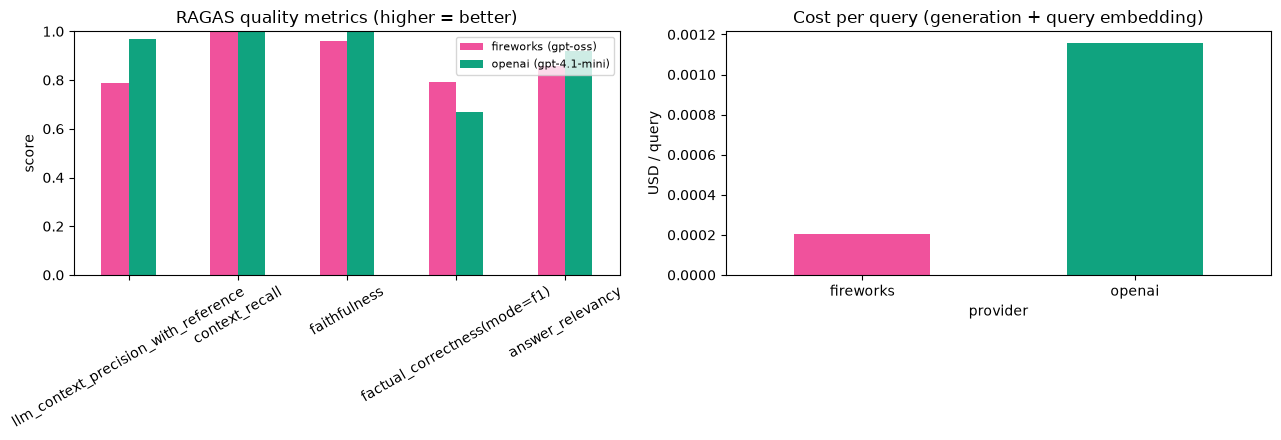

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# RAGAS quality
quality_df.plot(kind="bar", ax=axes[0], color=["#f0529c", "#10a37f"])
axes[0].set_title("RAGAS quality metrics (higher = better)")
axes[0].set_ylabel("score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=8)

# Cost per query
cost_df["cost_per_query_usd"].plot(
    kind="bar", ax=axes[1], color=["#f0529c", "#10a37f"]
)
axes[1].set_title("Cost per query (generation + query embedding)")
axes[1].set_ylabel("USD / query")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 8. Analysis

_Results from this run (10 questions, shared `gpt-4.1-mini` judge). Re-running will
vary these slightly — the judge is itself an LLM._

| Metric | Fireworks (gpt-oss) | OpenAI (gpt-4.1-mini) | Winner |
|---|---|---|---|
| Context precision (w/ ref) | 0.797 | **0.967** | OpenAI |
| Context recall | 1.000 | 1.000 | tie |
| Faithfulness | 0.992 | **1.000** | OpenAI |
| Factual correctness (F1) | **0.789** | 0.632 | Fireworks |
| Answer relevancy | 0.853 | **0.919** | OpenAI |
| **Cost / query** | **$0.00020** | $0.00116 | Fireworks (~5.7× cheaper) |
| Avg latency | **1.24 s** | 1.62 s | Fireworks |

**Retrieval quality.** Both stacks achieved perfect **context recall** (1.0) — with a
small 42-chunk corpus and `k=4`, the relevant passage is essentially always pulled in.
Where they diverged was **context precision**: OpenAI's `text-embedding-3-small`
(0.967) ranked the relevant chunks higher than Fireworks' `qwen3-embedding` (0.797),
so OpenAI's retrieved set contained less noise. Since both pipelines indexed the
*identical* chunks, this gap is attributable to the embedding model alone.

**Faithfulness.** Both generators stayed grounded in the retrieved context (0.99–1.00)
— unsurprising given the strict "only use the provided context" prompt. Neither model
meaningfully hallucinated.

**End-to-end accuracy.** Interestingly, `gpt-oss` scored *higher* on **factual
correctness** (0.789 vs 0.632). RAGAS factual-correctness is an F1 over claims, so it
rewards *completeness*: `gpt-oss` produced much longer answers (2,264 vs 567 total
output tokens) that covered more of the multi-part ground truths, whereas
`gpt-4.1-mini` gave terse answers (often 24–89 tokens) that omitted secondary details
and lost recall. `gpt-4.1-mini`'s answers were more relevant/on-point (answer
relevancy 0.919 vs 0.853) — a precision-vs-completeness trade-off.

**Cost.** The open-source stack was **~5.7× cheaper per query** ($0.00020 vs $0.00116)
and lower latency. `gpt-4.1-mini`'s per-token output price (16× the input price) drives
most of its cost even though it emits fewer tokens. Note the per-token figures assume
Fireworks **serverless** pricing; the dedicated endpoint used here actually bills by
**GPU-hour**, so its real effective cost depends on how fully you keep the endpoint
utilized (idle time is pure loss — hence the shutdown reminder).

**Takeaway.** For this knowledge base, the open-source Fireworks stack is the better
value: comparable (even better on completeness) answer accuracy at a fraction of the
cost and latency. OpenAI buys you tighter retrieval precision and more concise,
on-point answers. If concise, high-precision responses matter more than completeness —
or if you can't self-host — `gpt-4.1-mini` is justified; otherwise `gpt-oss` wins.

**LangSmith.** Open the **`session10-ragas-cost`** project in LangSmith to see every
traced run, token counts, and per-run cost side by side for the two providers.

---

**⚠️ Remember to SHUT DOWN your dedicated Fireworks endpoint when finished!**